In [1]:
import snapatac2 as snap
import pyarrow as pa
import polars as pl
import igraph as ig
import nbformat as nbf
import anndata as ad
import pandas as pd
import scanpy as sc
import numpy as np
import os
import sys
import plotly.io as pio
import matplotlib.pyplot as plt
import scvi
import skmisc

ModuleNotFoundError: No module named 'pandas.core.index'

In [1]:
import snapatac2 as snap    
import nbformat as nbf
import umap
import scvi
import numpy as np

/home/elliot/miniconda3/envs/atac_env_new2/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
data = snap.pp.import_data(
    "/mnt/claw-raid/elliot/Mike_keogh_mtscATAC/241121-cortex_results_masked/fragments.tsv.gz",
    chrom_sizes=snap.genome.hg38,  #
    sorted_by_barcode=False,
)
data          

/tmp/ipykernel_1783643/2861569763.py:1: DeprecationWarning: import_data is deprecated and will be removed in v2.9.0. Use import_fragments instead.
  data = snap.pp.import_data(


AnnData object with n_obs × n_vars = 65340 × 0
    obs: 'n_fragment', 'frac_dup', 'frac_mito'
    uns: 'reference_sequences'
    obsm: 'fragment_paired'

In [5]:
## Bit of extra information:
'''
1. Nucleosome-Free Region (NFR): The majority of fragments are short, typically around 80-300 base pairs (bp) in length. 
These short fragments represent regions of open chromatin where DNA is relatively accessible and not bound to nucleosomes. 
These regions are often referred to as nucleosome-free regions (NFRs) and correspond to regions of active transcriptional 
regulation.

2. Mono-Nucleosome Peaks: There is often a peak in the fragment size distribution at around 147-200 bp, 
which corresponds to the size of a single nucleosome wrapped DNA. These fragments result from the 
cutting of DNA by the transposase enzyme when it encounters a nucleosome, 
causing the DNA to be protected and resulting in fragments of the same size.

3. Di-Nucleosome Peaks: In addition to the mono-nucleosome peak, you may also observe 
a smaller peak at approximately 300-400 bp, corresponding to di-nucleosome fragments. 
These fragments occur when transposase cuts the DNA between two neighboring nucleosomes.

4. Large Fragments: Some larger fragments, greater than 500 bp in size, may be observed. 
These fragments can result from various sources, such as the presence of 
longer stretches of open chromatin or technical artifacts.
'''

#Idk why this isn't wokring something to do with chrome wtf

snap.pl.frag_size_distr(data, interactive=False)

ValueError: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido


In [6]:
## Same plot with axis to log scale
fig = snap.pl.frag_size_distr(data, show=False)
fig.update_yaxes(type="log")
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [ ]:
## TSS enrichment implies there is an increased accessibility or fragmentation of chromatin around the TSS
## Often indicative of promoter regions
snap.metrics.tsse(data, snap.genome.hg38)

In [ ]:
## To identify usable/high-quality cells, we can plot TSSe scores against number of unique fragments for each cell.
snap.pl.tsse(data, interactive=True)
data
##The cells in the upper right represent valid or high-quality cells, whereas those in the lower left represent low-quality 
# cells or empty droplets. Based on this plot, 
#we decided to set a minimum TSS enrichment of 10 and a minimum number of fragments of 5,000 to filter the cells.

/home/elliot/miniconda3/envs/atac_env_new2/lib/python3.9/site-packages/snapatac2/plotting/__init__.py:97: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x = adata.obs["n_fragment"][selected_cells]
/home/elliot/miniconda3/envs/atac_env_new2/lib/python3.9/site-packages/snapatac2/plotting/__init__.py:98: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y = adata.obs["tsse"][selected_cells]
/home/elliot/miniconda3/envs/atac_env_new2/lib/python3.9/site-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 

AnnData object with n_obs × n_vars = 65340 × 0
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse'
    uns: 'reference_sequences', 'library_tsse', 'frac_overlap_TSS', 'TSS_profile'
    obsm: 'fragment_paired'

In [ ]:
## OprionL - Filtering cells here results in fewer mitochondrial variants deteced
snap.pp.filter_cells(data, min_counts=1000, min_tsse=10, max_counts=100000)
data

AnnData object with n_obs × n_vars = 1228 × 0
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse'
    uns: 'reference_sequences', 'library_tsse', 'frac_overlap_TSS', 'TSS_profile'
    obsm: 'fragment_paired'

In [ ]:
## Cell by bin matrix containng insertion counts across 500bp bins across the genome
snap.pp.add_tile_matrix(data)

In [ ]:
## Feature selection, which will be stored in data.var['selected'] this is particularly relevant for scrublet and spectral
## Selects most accessible features 
## n_features determines number of features, experiment with n_features to find the optimal number for your dataset
snap.pp.select_features(data, n_features=250000)

2025-11-20 19:51:28 - INFO - Selected 250000 features.


In [ ]:

## Scrublet is used to remove potential dublets. It will assign probabilities to each cell, and then we can filter
snap.pp.scrublet(data)
#snap.pp.scrublet(data)
snap.pp.filter_doublets(data)
data

2025-11-20 19:51:31 - INFO - Simulating doublets...
2025-11-20 19:51:31 - INFO - Spectral embedding ...
2025-11-20 19:51:56 - INFO - Calculating doublet scores...
2025-11-20 19:51:57 - INFO - Detected doublet rate = 1.303%


AnnData object with n_obs × n_vars = 1212 × 6062095
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse', 'doublet_probability', 'doublet_score'
    var: 'count', 'selected'
    uns: 'reference_sequences', 'library_tsse', 'frac_overlap_TSS', 'TSS_profile', 'scrublet_sim_doublet_score', 'doublet_rate'
    obsm: 'fragment_paired'

In [ ]:
## Spectral embedding is used for dimensionality reduction
## Stored in data.obsm['X_spectral']
snap.tl.spectral(data)
snap.tl.umap(data)

/home/elliot/miniconda3/envs/atac_env_new2/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [ ]:
## Perform graph based clustering, build k-nearest neighbour graph then use leiden algorithm to identify clusters
snap.pp.knn(data)
snap.tl.leiden(data, resolution=0.7)  # Adjust resolution for more or fewer clusters

AttributeError: `np.compat` was removed in the NumPy 2.0 release. There's no replacement, as Python 2 is no longer supported.

In [ ]:
snap.pl.umap(data, color='leiden', interactive=True, height=500)

In [ ]:
#ELLIOT - lucas' Clustering done annotation begins 
## Annotate the clusters and assign them to known cell types
## Compute gene activities for each cell using pp.make_gene_matrix

gene_matrix = snap.pp.make_gene_matrix(
    data, 
    gene_anno=snap.genome.hg38,
    gene_name_key='gene_id'  # Use Ensembl IDs instead of gene symbols
)

# Remove version numbers from Ensembl IDs
gene_matrix.var_names = gene_matrix.var_names.str.replace(r'\.\d+$', '', regex=True)


In [ ]:
#ELLIOT - Lucas' annotation method 
#import RNA reference data

reference = sc.read_h5ad('/mnt/claw-raid/elliot/brainvasc_ref.h5ad')
reference


# Check the cell type column name in your reference
print(reference.obs.columns)  # Find which column has cell types


Index(['author_cell_type', 'cell_type_ontology_term_id', 'donor_id',
       'development_stage_ontology_term_id', 'sex_ontology_term_id',
       'disease_ontology_term_id', 'is_primary_data', 'suspension_type',
       'tissue_ontology_term_id', 'tissue_type', 'assay_ontology_term_id',
       'self_reported_ethnicity_ontology_term_id', 'cell_type', 'assay',
       'disease', 'sex', 'tissue', 'self_reported_ethnicity',
       'development_stage', 'observation_joinid'],
      dtype='object')


In [ ]:
#ELLIOT - Merge reference data and query data

# CRITICAL: Convert reference to use Ensembl IDs
reference.var_names = reference.var['ensembl_id'].values
reference.var_names_make_unique()

# Now merge
gene_matrix.obs['cell_type'] = 'Unknown'
integrated = ad.concat(  # ← Fixed typo: intergrated → integrated
    [reference, gene_matrix],
    join='inner',
    label='batch',
    keys=["reference", "query"],
    index_unique='_',
)

print(f"Combined shape: {integrated.shape}")

Combined shape: (66691, 30704)


/home/elliot/miniconda3/envs/atac_env_new2/lib/python3.9/site-packages/anndata/_core/merge.py:1358: UserWarning:

Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.



In [ ]:
# scanpy finds highly variable genes (batch correction)
#if you ask callum he will say this is shit because this is porabbly just to make it faster
sc.pp.filter_genes(integrated, min_cells=5)
#find hvg
sc.pp.highly_variable_genes(
    integrated,
    n_top_genes = 5000,
    flavor="seurat_v3",
    batch_key="batch",
    subset=True
)

/home/elliot/miniconda3/envs/atac_env_new2/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:75: UserWarning:

`flavor='seurat_v3'` expects raw count data, but non-integers were found.



In [ ]:
#set up machine learning 
scvi.model.SCVI.setup_anndata(integrated, batch_key="batch")
vae = scvi.model.SCVI(
    integrated,
    n_layers=2,
    n_latent=30,
    gene_likelihood="nb",
    dispersion="gene-batch",
)

AttributeError: module 'scvi' has no attribute 'model'

In [24]:
#pretraining model?
vae.train(max_epochs=100, early_stopping=True)


/home/elliot/miniconda3/envs/atac_env/lib/python3.9/site-packages/lightning/fabric/plugins/environments/slurm.py:204: PossibleUserWarning:

The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/elliot/miniconda3/envs/atac_env/lib/python3.9/ ...

INFO: GPU available: False, used: False
2025-11-20 12:11:46 - INFO - GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
2025-11-20 12:11:46 - INFO - TPU available: False, using: 0 TPU cores
/home/elliot/miniconda3/envs/atac_env/lib/python3.9/site-packages/lightning/fabric/plugins/environments/slurm.py:204: PossibleUserWarning:

The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/elliot/miniconda3/envs/atac_env/lib/python3.9/ ...

/home/elliot/miniconda3/en

Epoch 100/100: 100%|██████████| 100/100 [17:30<00:00, 10.51s/it, v_num=1, train_loss_step=768, train_loss_epoch=690]

INFO: `Trainer.fit` stopped: `max_epochs=100` reached.
2025-11-20 12:29:16 - INFO - `Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████| 100/100 [17:30<00:00, 10.50s/it, v_num=1, train_loss_step=768, train_loss_epoch=690]


<Axes: xlabel='epoch'>

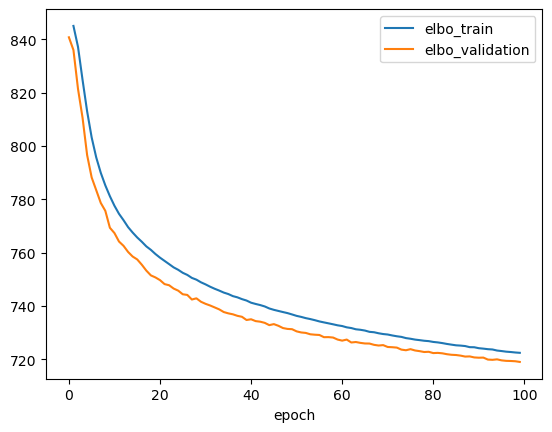

In [26]:
#plot training model to make sure it has converged 
ax = vae.history['elbo_train'][1:].plot()
vae.history['elbo_validation'].plot(ax=ax)


In [27]:
#setting up training model, check the 'class' or quivalent column is presetn in the refernce an merged object 
integrated.obs["celltype_scanvi"] = 'Unknown'
ref_idx = integrated.obs['batch'] == "reference"
integrated.obs.loc[ref_idx, "celltype_scanvi"] = integrated.obs.loc[ref_idx, 'cell_type'].astype(str) 


In [28]:
#who knows what this does maybe callum 
lvae = scvi.model.SCANVI.from_scvi_model(
    vae,
    adata=integrated,
    labels_key="celltype_scanvi",
    unlabeled_category="Unknown",
)

/home/elliot/miniconda3/envs/atac_env/lib/python3.9/site-packages/scvi/data/fields/_base_field.py:64: UserWarning:

adata.X does not contain unnormalized count data. Are you sure this is what you want?



In [29]:
lvae.train(max_epochs=100, n_samples_per_label=100, early_stopping=True)

INFO     Training for 100 epochs.                                                                                  


/home/elliot/miniconda3/envs/atac_env/lib/python3.9/site-packages/lightning/fabric/plugins/environments/slurm.py:204: PossibleUserWarning:

The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/elliot/miniconda3/envs/atac_env/lib/python3.9/ ...

INFO: GPU available: False, used: False
2025-11-20 12:29:42 - INFO - GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
2025-11-20 12:29:42 - INFO - TPU available: False, using: 0 TPU cores
/home/elliot/miniconda3/envs/atac_env/lib/python3.9/site-packages/lightning/fabric/plugins/environments/slurm.py:204: PossibleUserWarning:

The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/elliot/miniconda3/envs/atac_env/lib/python3.9/ ...

/home/elliot/miniconda3/en

Epoch 100/100: 100%|██████████| 100/100 [41:37<00:00, 24.92s/it, v_num=1, train_loss_step=808, train_loss_epoch=686]

INFO: `Trainer.fit` stopped: `max_epochs=100` reached.
2025-11-20 13:11:20 - INFO - `Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████| 100/100 [41:37<00:00, 24.97s/it, v_num=1, train_loss_step=808, train_loss_epoch=686]


<Axes: xlabel='epoch'>

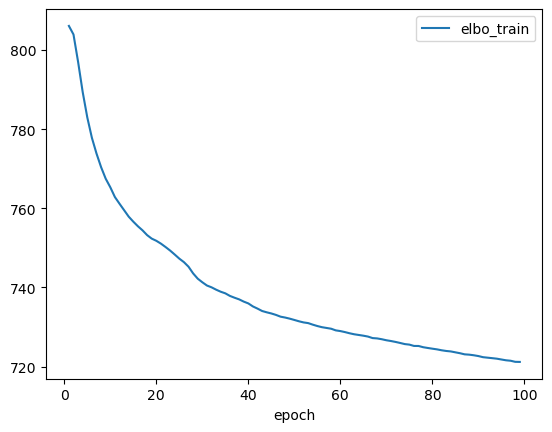

In [30]:
#plotting history as normal (if not saved)
lvae.history['elbo_train'][1:].plot()


In [31]:
# Now you can use the model
integrated.obs["C_scANVI"] = lvae.predict()
integrated.obsm["X_scANVI"] = lvae.get_latent_representation()

In [32]:
#generating uMAP
sc.pp.neighbors(integrated, use_rep="X_scANVI")
sc.tl.umap(integrated)

... storing 'cell_type' as categorical
... storing 'celltype_scanvi' as categorical
... storing 'C_scANVI' as categorical


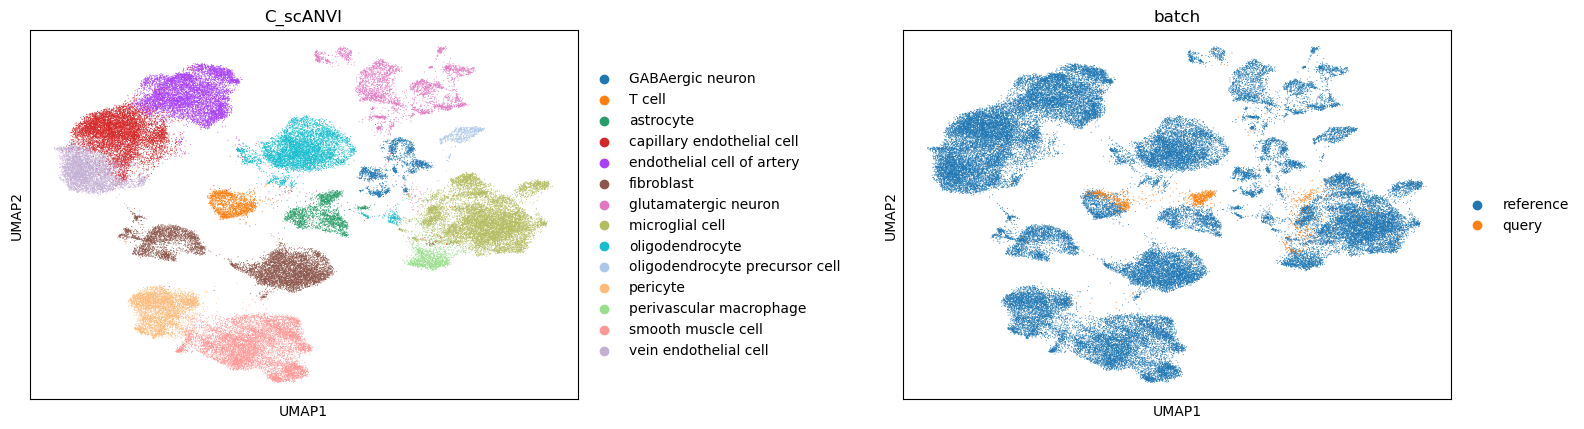

In [33]:
#Plotting uMAP querey and reference
sc.pl.umap(integrated, color=['C_scANVI', "batch"], wspace=0.45)


In [3]:
# Transfer predicted cell types back to original SnapATAC2 object
data.obs['cell_type'] = integrated.obs.loc[data.obs_names + '_query', 'C_scANVI'].to_numpy()

NameError: name 'integrated' is not defined

In [12]:
sc.pl.umap(data  , color=['cell_type', "leiden"], wspace=0.45)


AttributeError: 'builtins.AnnData' object has no attribute '_sanitize'

In [15]:
# Use SnapATAC2's built-in UMAP plotting
print("Plotting UMAP with SnapATAC2...")
snap.pl.umap(data, color='cell_type', interactive=True, height=500, show=True)

Plotting UMAP with SnapATAC2...


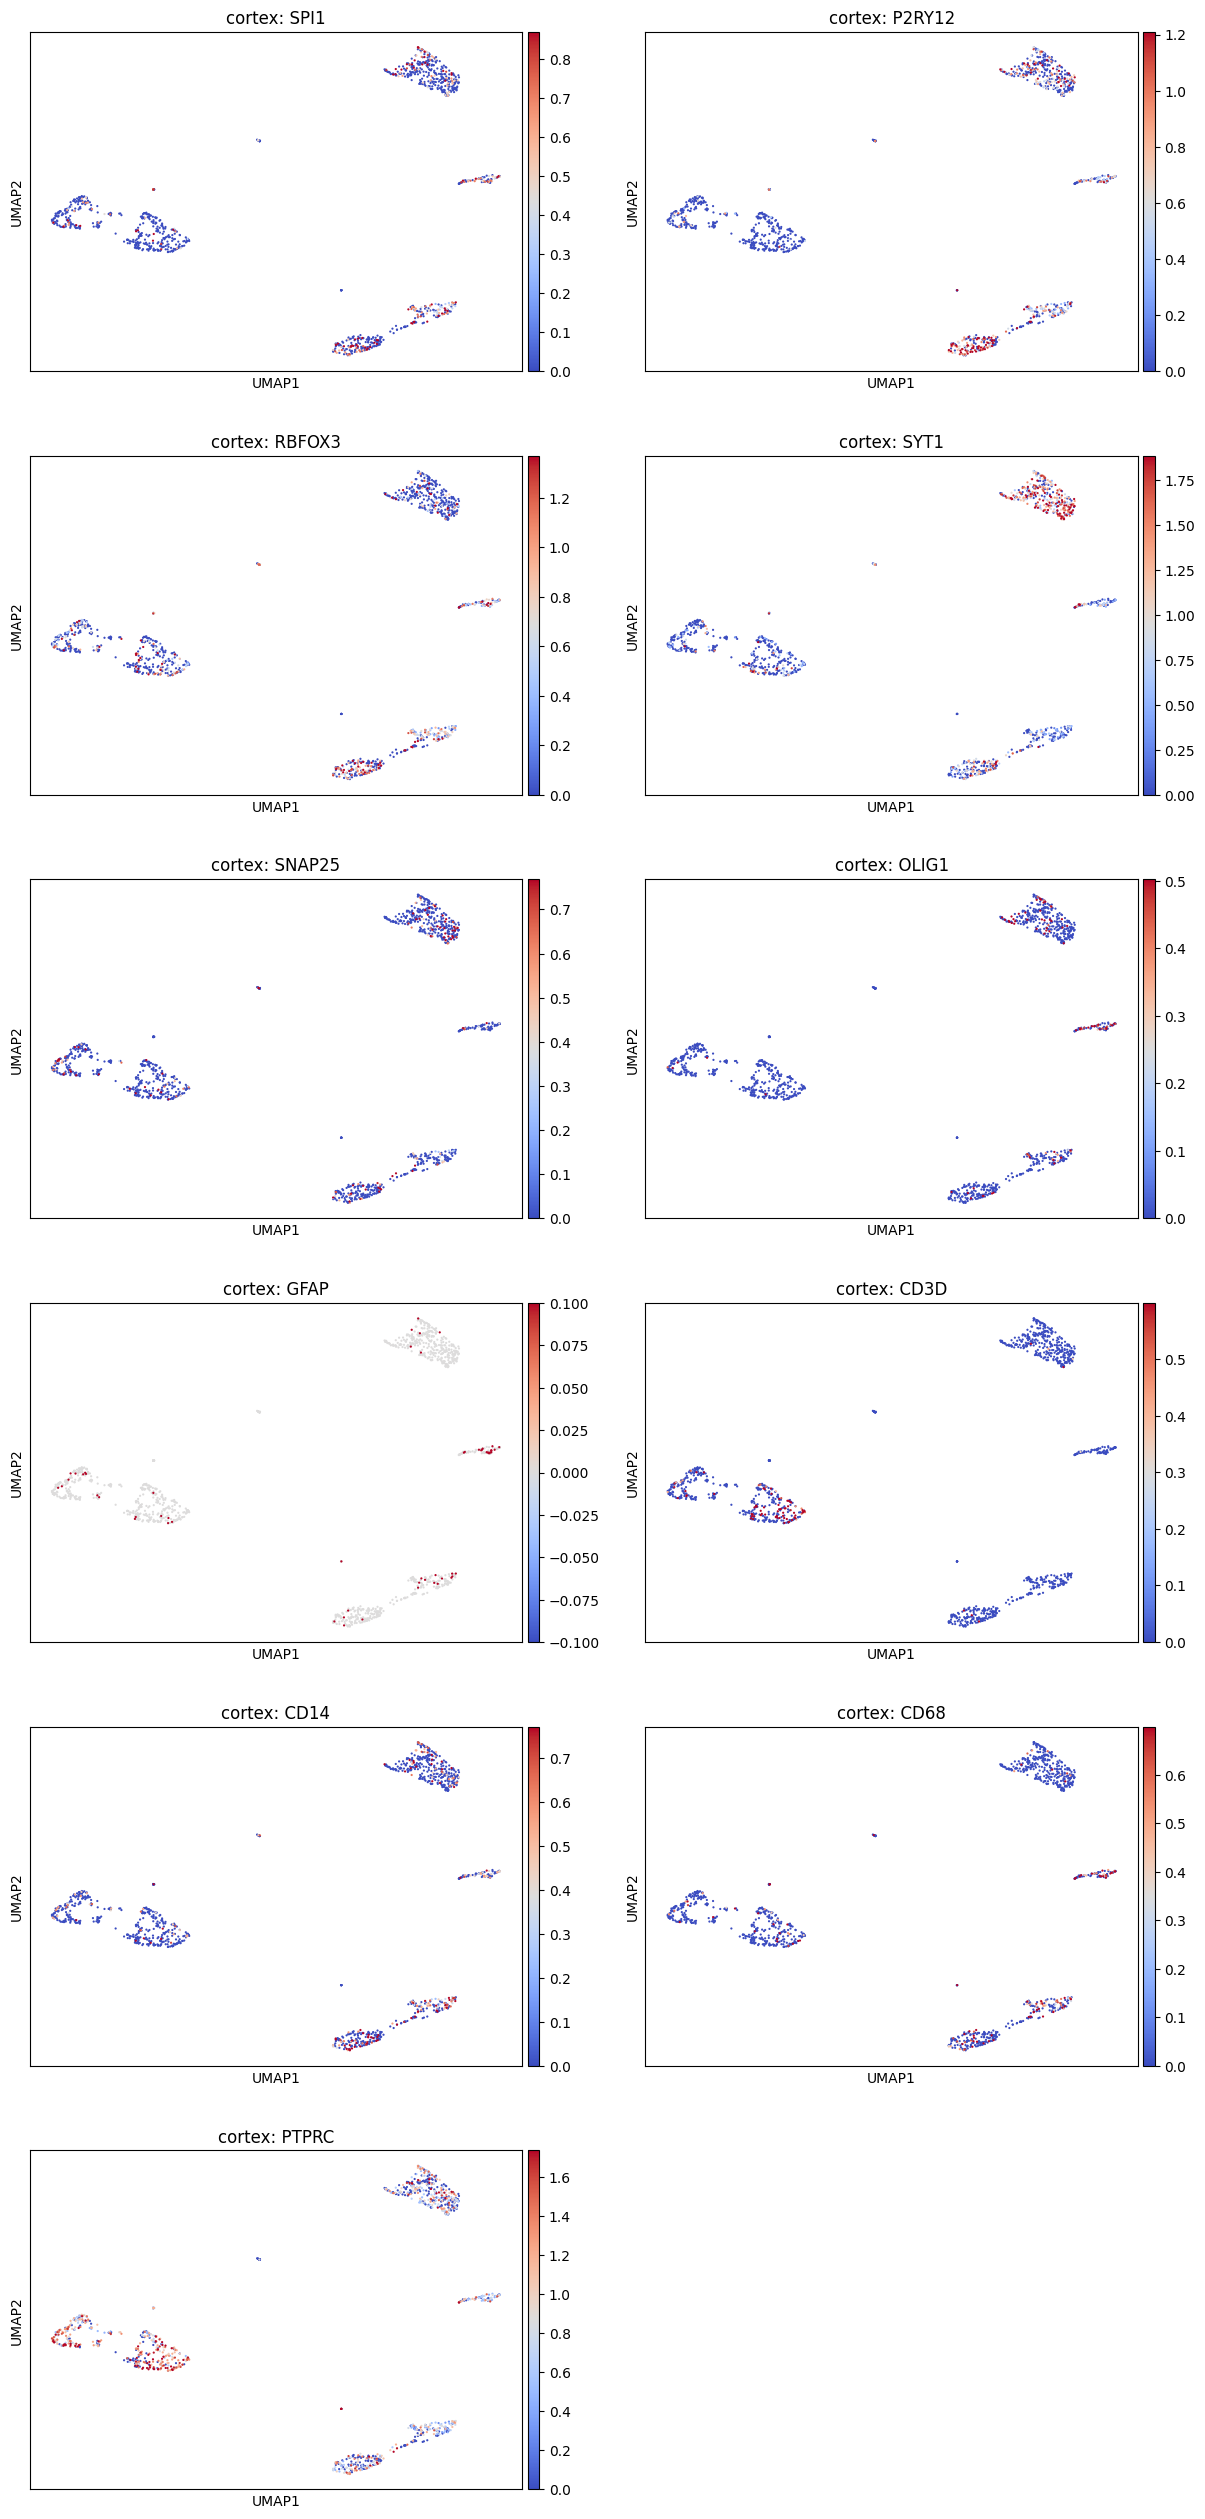

In [ ]:
import matplotlib.pyplot as plt

# Define marker genes for each cell type
celltype_markers = {
    #'PBMCs': ["CD4","CD8A","CD3D","NCAM1","FCGR3A","CD14","CD1C","CLEC9A","IL3RA","GZMB","C5AR1","CD34","CD19","MS4A1"], ## PTPRC is CD45, sample should be 70/30 CD4+/CD4-
    'cortex': ["SPI1","P2RY12","RBFOX3","SYT1","SNAP25","OLIG1","GFAP","CD3D","CD14","CD68","PTPRC"],
  
}

# Plot UMAPs for each cell type's marker genes
for celltype, genes in celltype_markers.items():
    sc.pl.umap(
        gene_matrix, 
        color=genes, 
        ncols=2, 
        cmap='coolwarm',
        vmax='p95',
        size=10,
        title=[f"{celltype}: {gene}" for gene in genes],
        show=True
    )
plt.show()


In [ ]:
#Elliot - mkaing a DEGs list actually, gene_matrix is an object NOT an acutal matrix 

# Get the number of top genes (should be 20 based on your plot)
n_genes = len(gene_matrix.uns['rank_genes_groups']['names'])

# Create a dictionary with DEG lists for each cluster
deg_lists = {}
for i in range(n_genes):
    for j, cluster in enumerate(gene_matrix.uns['rank_genes_groups']['names'].dtype.names):
        if cluster not in deg_lists:
            deg_lists[cluster] = []
        deg_lists[cluster].append(gene_matrix.uns['rank_genes_groups']['names'][i][j])

# Now deg_lists contains clean lists of top DEGs for each cluster
for cluster, genes in deg_lists.items():
    print(f"Cluster {cluster}: {genes[:20]}...")  # Show first 5 genes

Cluster 0: ['LRP1B', 'GRID2', 'ENSG00000231918', 'CNTN5', 'CNTNAP2', 'DPP10', 'ENSG00000251574', 'EYS', 'ROBO2', 'ERBB4', 'DMD', 'NAALADL2', 'CSMD3', 'ENSG00000254394', 'CDH18', 'RBMS3', 'ROBO1', 'ENSG00000248752', 'SPAG16', 'CADM2']...
Cluster 1: ['PELATON', 'CDH23', 'ENSG00000285565', 'RAD51B', 'PSAP', 'DAPK1', 'SLC24A4', 'PGS1', 'ENSG00000234261', 'PFKFB3', 'ZMIZ1', 'ENSG00000273112', 'HSPD1', 'MGAT1', 'BAG3', 'MBP', 'HSPH1', 'ENSG00000285016', 'DNAJB6', 'XYLT1']...
Cluster 2: ['ENSG00000234261', 'LINC00877', 'SCIRT', 'ENSG00000258137', 'HK2', 'JARID2', 'ZMIZ1', 'ENSG00000258086', 'CUX1', 'PRKAG2', 'RBM47', 'RIN2', 'SLCO3A1', 'GAS7', 'RFX2', 'NCOR2', 'TIMP2', 'ENSG00000289728', 'DMXL2', 'FNDC3B']...
Cluster 3: ['HK2', 'CUX1', 'FNDC3B', 'RUNX1', 'PRKAG2', 'MAML3', 'JARID2', 'ASAP1', 'ENSG00000289728', 'DOCK5', 'ENSG00000259345', 'SLCO3A1', 'RPTOR', 'SLC24A4', 'ENSG00000286022', 'IGF2BP2', 'DOCK2', 'PPARG', 'LUCAT1', 'NIBAN2']...
Cluster 4: ['BCL11B', 'RORA', 'RORA-AS1', 'SCML4', 'ITK

... storing 'leiden' as categorical


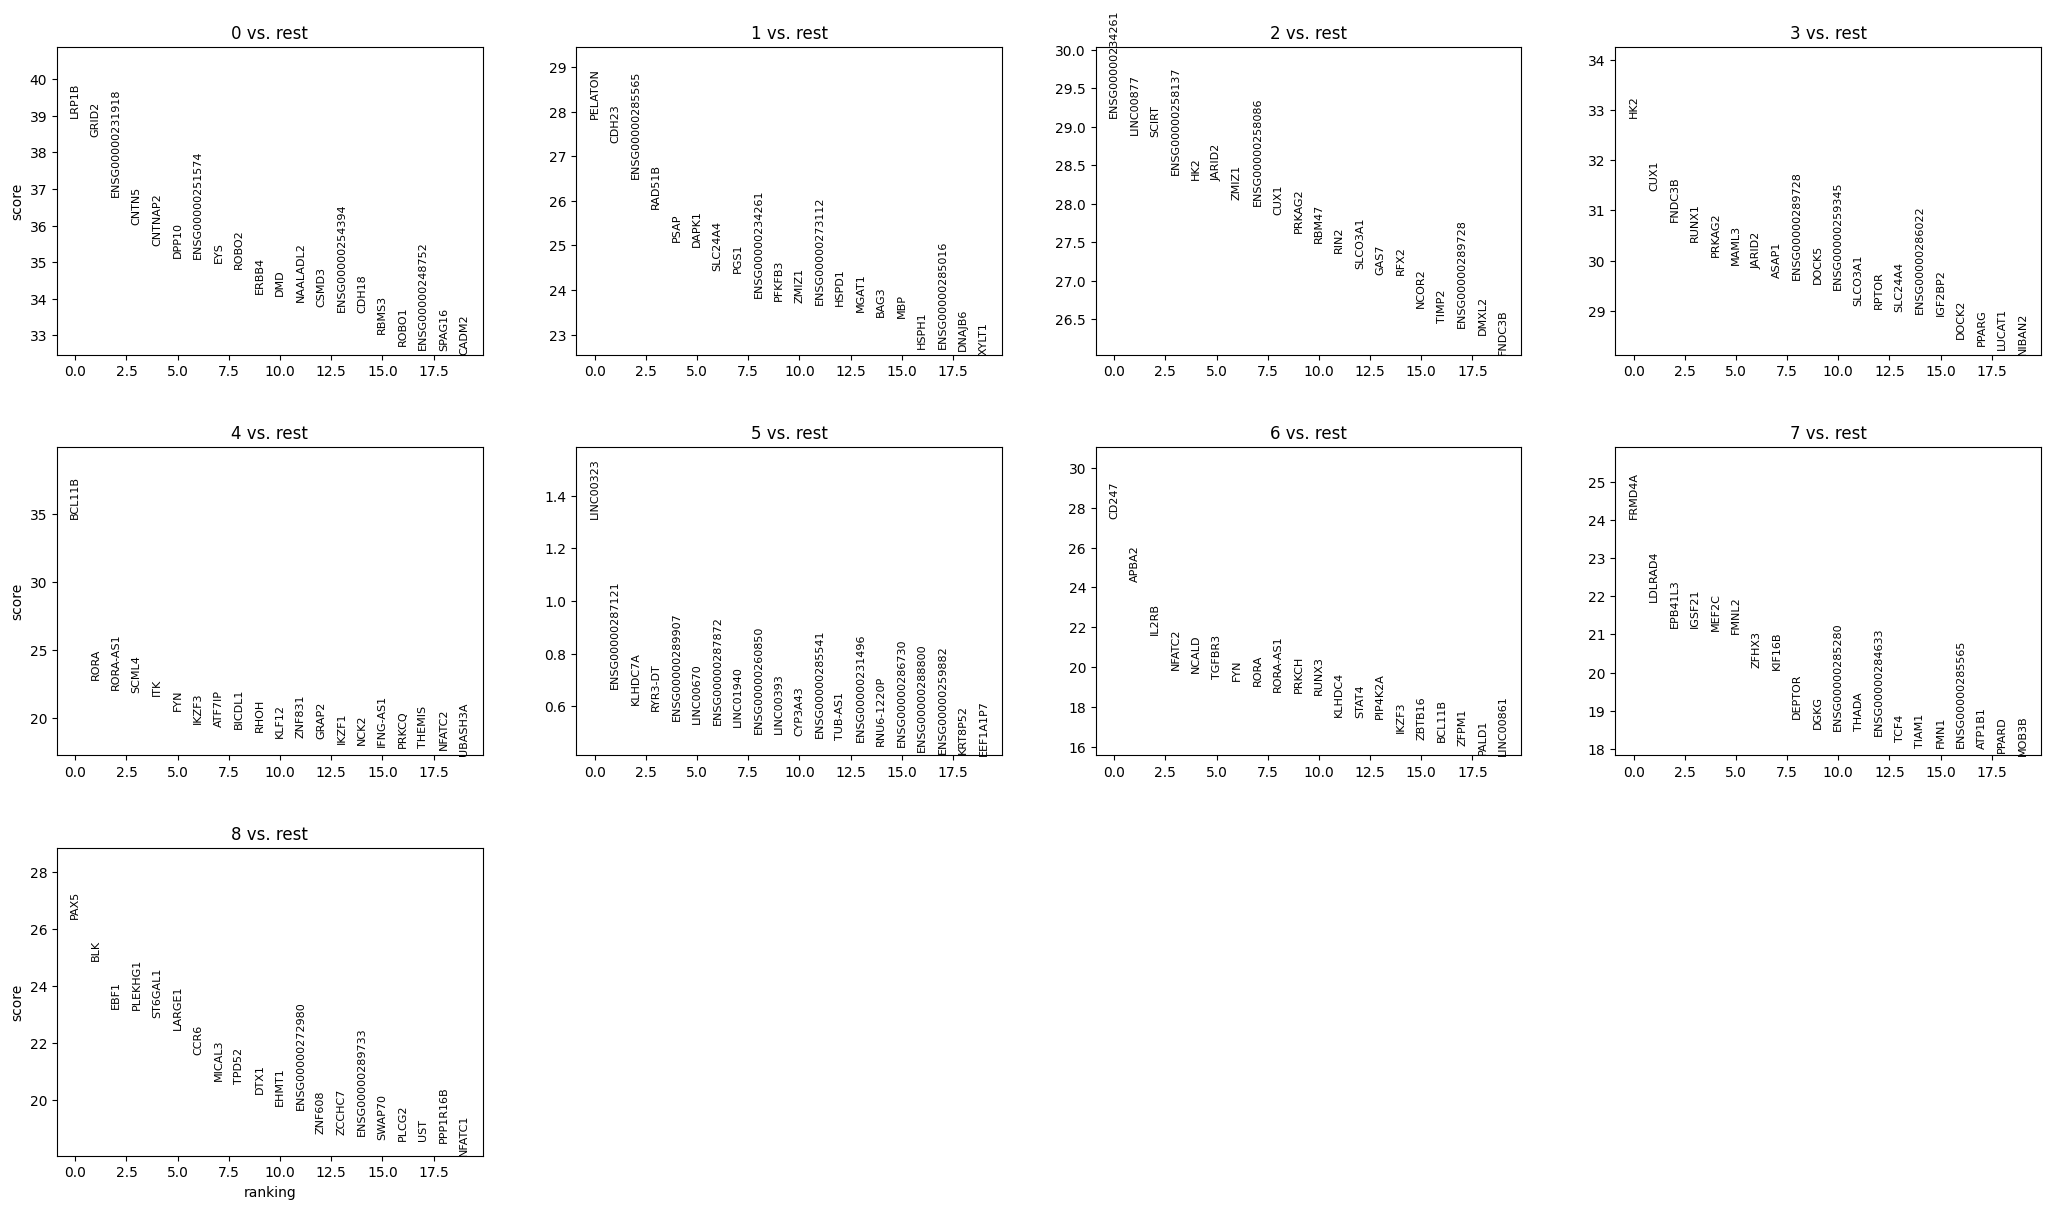

In [ ]:
# Run differential expression analysis between clusters (e.g., 'leiden' clusters)
sc.tl.rank_genes_groups(gene_matrix, groupby='leiden', method='wilcoxon')

# Show the top marker genes for each cluster
sc.pl.rank_genes_groups(gene_matrix, n_genes=20, sharey=False)



In [ ]:
# !!!!!!!!!!!!!!!!!! !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!OK SO NOW THE MT VARIANT CALLING BEGINS STOP HERE !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

In [4]:
x = 1

In [5]:
data = sc.read_h5ad("/mnt/claw-raid/elliot/atac_PM_annotated/atac_data_annotated.h5ad")


In [6]:
import sys
sys.path.insert(0, '/mnt/claw-raid/elliot/Py_mTCall_tools/Py_mTCall_tools')
import variant_calling_fast as vc
mgatk = vc.process_variants_fast("/mnt/claw-raid/elliot/Mike_keogh_mtscATAC/241121-cortex_results_masked/mgatk_output/final", data)


=== Fast Variant Calling Pipeline ===
Loaded counts data: (123429, 2406)
Loaded coverage data: (31156445, 3)
Identifying variants (memory-optimized chunked method)...
Processing all 90293 variant observations (no artificial limits)
Integrating with AnnData...
=== Pipeline Complete ===
Processed 1083 variants in 1424 matching cells


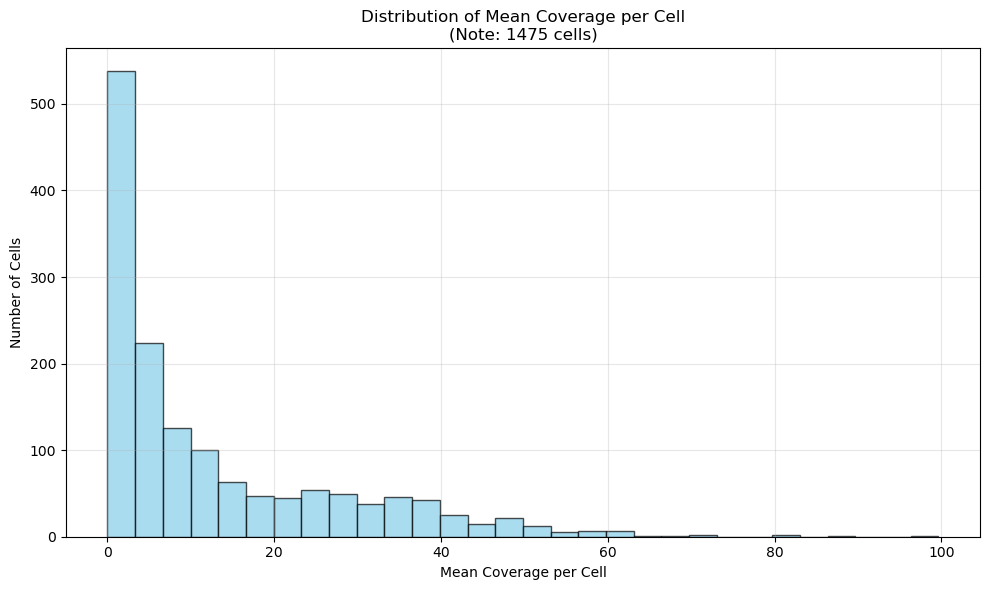

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Get coverage data from the correct location
coverage_matrix = mgatk.obsm['variant_coverage']
mean_coverage_per_cell = np.mean(coverage_matrix, axis=1)

# Create the distribution plot
plt.figure(figsize=(10, 6))
plt.hist(mean_coverage_per_cell, bins=30, alpha=0.7, edgecolor='black', color='skyblue')

plt.xlabel('Mean Coverage per Cell')
plt.ylabel('Number of Cells')
plt.title(f'Distribution of Mean Coverage per Cell\n(Note: {len(mean_coverage_per_cell)} cells)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Plotting first 5 confident variants out of 1083 total confident variants
Processing variant 1: Index 0, Name: A-10500-G
No confident non-zero calls for variant A-10500-G
Processing variant 2: Index 1, Name: A-10925-T


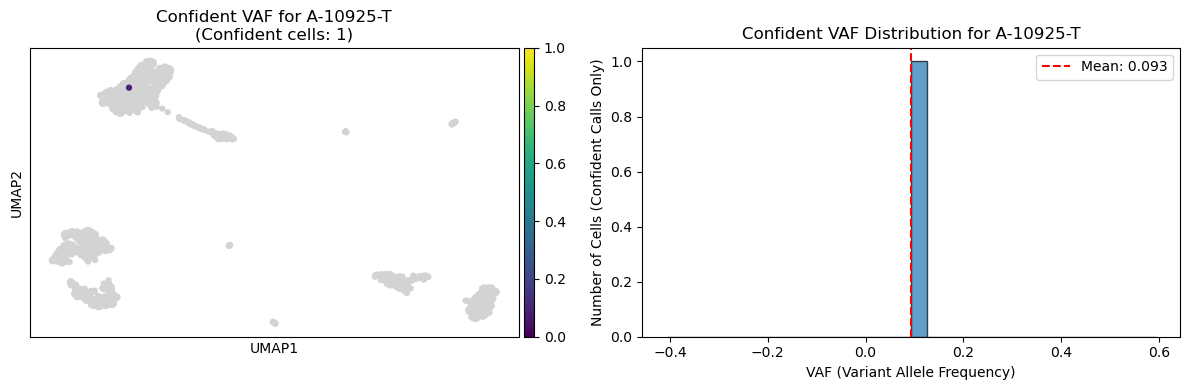

Variant A-10925-T (Index 1):
  Confident cells detected: 1
  Mean coverage: 13.2
  Total cells: 1475
  Confident calls: [False False False ... False False False]
  Confident non-zero calls: 1
  Mean confident VAF: 0.093
  Confident VAF range: 0.093 - 0.093
---
Processing variant 3: Index 2, Name: A-11719-G


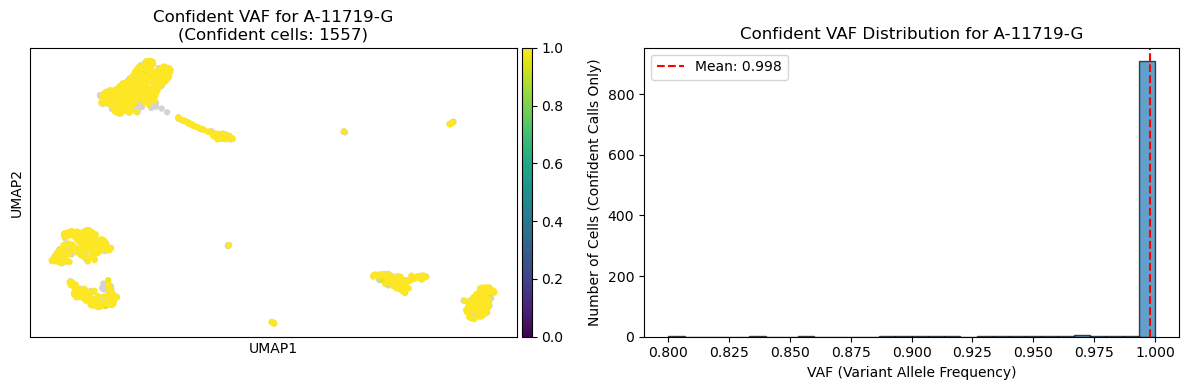

Variant A-11719-G (Index 2):
  Confident cells detected: 1557
  Mean coverage: 14.3
  Total cells: 1475
  Confident calls: [ True  True False ... False False  True]
  Confident non-zero calls: 943
  Mean confident VAF: 0.998
  Confident VAF range: 0.800 - 1.000
---
Processing variant 4: Index 3, Name: A-11802-T
No confident non-zero calls for variant A-11802-T
Processing variant 5: Index 4, Name: A-11838-T


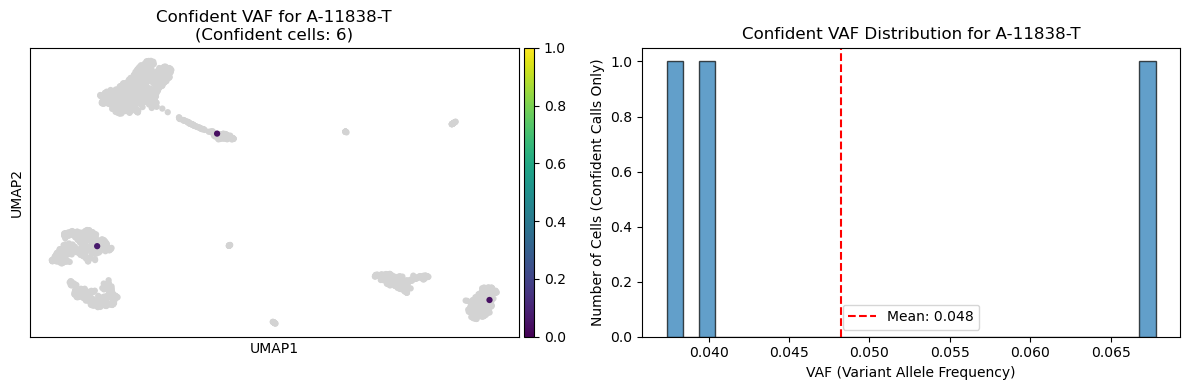

Variant A-11838-T (Index 4):
  Confident cells detected: 6
  Mean coverage: 17.2
  Total cells: 1475
  Confident calls: [ True False False ... False False False]
  Confident non-zero calls: 3
  Mean confident VAF: 0.048
  Confident VAF range: 0.037 - 0.068
---


In [8]:
# Plot confident variants with UMAP and VAF distribution
import matplotlib.pyplot as plt
import numpy as np

# Get confident variants (those with at least one cell having confident detection)
confident_variants = mgatk.uns['variant_summary'][mgatk.uns['variant_summary']['n_cells_conf_detected'] > 0]

print(f"Plotting first 5 confident variants out of {len(confident_variants)} total confident variants")

# Get the variant names list
variant_names = mgatk.uns['variant_names']

for i, variant_idx in enumerate(confident_variants.index[:5]):  # Plot top 5 confident variants
    # variant_idx is already the integer index we need
    variant_name = variant_names[variant_idx]  # Get the actual variant name string
    
    print(f"Processing variant {i+1}: Index {variant_idx}, Name: {variant_name}")
    
    # Get VAF and confident matrices
    vaf_matrix = mgatk.obsm['variant_vaf']
    confident_matrix = mgatk.obsm['variant_confident']
    
    # Extract VAF and confidence for this specific variant using the integer index
    vaf_values = vaf_matrix[:, variant_idx]
    confident_calls = confident_matrix[:, variant_idx]
    
    # Filter for confident calls AND non-zero VAF
    confident_and_nonzero_mask = confident_calls & (vaf_values > 0)
    
    if not confident_and_nonzero_mask.any():
        print(f"No confident non-zero calls for variant {variant_name}")
        continue
    
    # Get filtered VAF values
    filtered_vaf_values = vaf_values[confident_and_nonzero_mask]
    
    # Create a temporary column for plotting (confident calls only)
    temp_vaf_col = np.zeros(len(mgatk.obs))
    temp_vaf_col[confident_and_nonzero_mask] = filtered_vaf_values
    # Set non-confident or zero calls to NaN for proper plotting
    temp_vaf_col[~confident_and_nonzero_mask] = np.nan
    
    # Add temporary column to obs for plotting
    mgatk.obs[f'temp_vaf_{variant_idx}'] = temp_vaf_col
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # UMAP plot (only confident calls will be colored)
    sc.pl.umap(mgatk, color=f'temp_vaf_{variant_idx}', cmap="viridis", vmin=0, vmax=1, 
               title=f"Confident VAF for {variant_name}\n(Confident cells: {confident_variants.loc[variant_idx, 'n_cells_conf_detected']})", 
               ax=ax1, show=False, na_color='lightgray')
    
    # Histogram of confident VAF values only
    ax2.hist(filtered_vaf_values, bins=30, alpha=0.7, edgecolor='black')
    ax2.set_xlabel('VAF (Variant Allele Frequency)')
    ax2.set_ylabel('Number of Cells (Confident Calls Only)')
    ax2.set_title(f'Confident VAF Distribution for {variant_name}')
    ax2.axvline(filtered_vaf_values.mean(), color='red', linestyle='--', 
                label=f'Mean: {filtered_vaf_values.mean():.3f}')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    total_cells = len(mgatk.obs)
    confident_cells = confident_calls.sum()
    confident_nonzero_cells = len(filtered_vaf_values)
    
    print(f"Variant {variant_name} (Index {variant_idx}):")
    print(f"  Confident cells detected: {confident_variants.loc[variant_idx, 'n_cells_conf_detected']}")
    print(f"  Mean coverage: {confident_variants.loc[variant_idx, 'mean_coverage']:.1f}")
    print(f"  Total cells: {total_cells}")
    print(f"  Confident calls: {confident_calls}")
    print(f"  Confident non-zero calls: {confident_nonzero_cells}")
    print(f"  Mean confident VAF: {filtered_vaf_values.mean():.3f}")
    print(f"  Confident VAF range: {filtered_vaf_values.min():.3f} - {filtered_vaf_values.max():.3f}")
    print("---")
    
    # Clean up temporary column
    mgatk.obs.drop(columns=[f'temp_vaf_{variant_idx}'], inplace=True)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Convert to dense array if sparse
coverage_matrix = mgatk.X
if hasattr(coverage_matrix, 'toarray'):
    coverage_matrix = coverage_matrix.toarray()

print(f"Coverage matrix shape: {coverage_matrix.shape}")

# Get cell names
cell_names = mgatk.obs_names

# Create the plot
plt.figure(figsize=(15, 10))

# Plot each cell as a line
for i, cell_name in enumerate(cell_names):
    coverage = coverage_matrix[i, :]
    # Ensure both x and y have same dimensions
    x_positions = range(len(coverage))
    plt.plot(x_positions, coverage, alpha=0.7, linewidth=1, label=cell_name)

plt.xlabel('Position on Mitochondrial Genome')
plt.ylabel('Read Depth')
plt.title('Mitochondrial Genome Coverage for All Cells')
plt.grid(True, alpha=0.3)

# Only show legend if there aren't too many cells
if len(cell_names) <= 20:
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Coverage matrix shape: (1475, 6062095)


KeyboardInterrupt: 

Variant A-10500-G: Insufficient data points (0)
Variant A-10925-T: Insufficient data points (1)


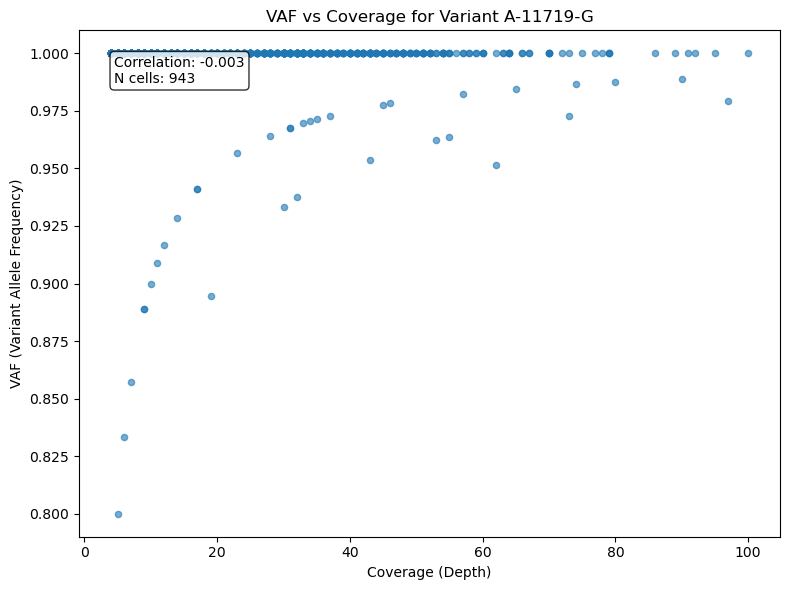

Variant A-11719-G:
  Coverage range: 4.0 - 100.0
  Mean coverage: 21.9
  VAF range: 0.800 - 1.000
  Correlation (VAF vs Coverage): -0.003
---
Variant A-11802-T: Insufficient data points (0)
Variant A-11838-T: Insufficient data points (3)
Variant A-15170-G: Insufficient data points (2)


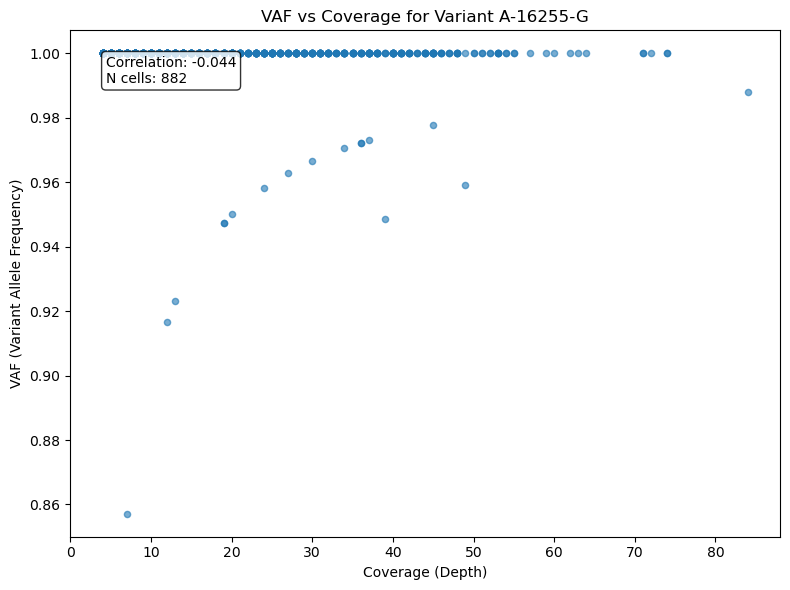

Variant A-16255-G:
  Coverage range: 4.0 - 84.0
  Mean coverage: 18.4
  VAF range: 0.857 - 1.000
  Correlation (VAF vs Coverage): -0.044
---


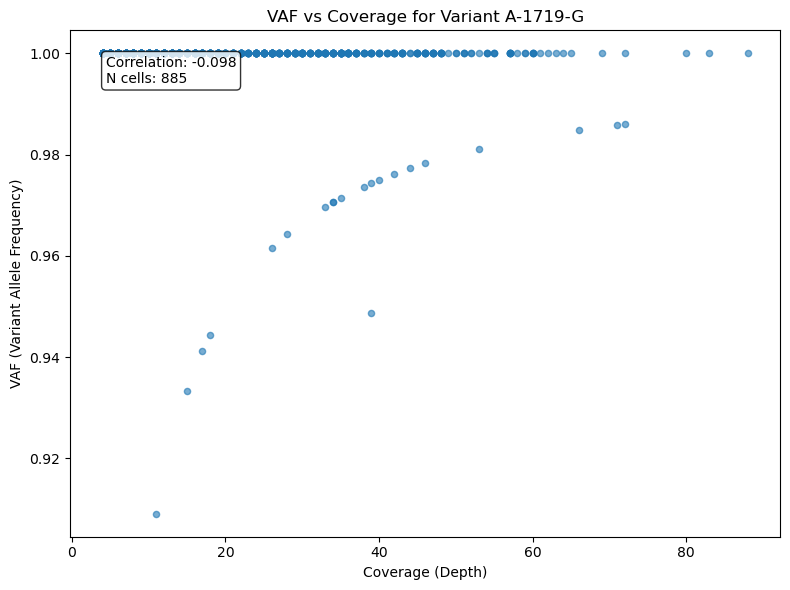

Variant A-1719-G:
  Coverage range: 4.0 - 88.0
  Mean coverage: 19.7
  VAF range: 0.909 - 1.000
  Correlation (VAF vs Coverage): -0.098
---
Variant A-1770-G: Insufficient data points (1)


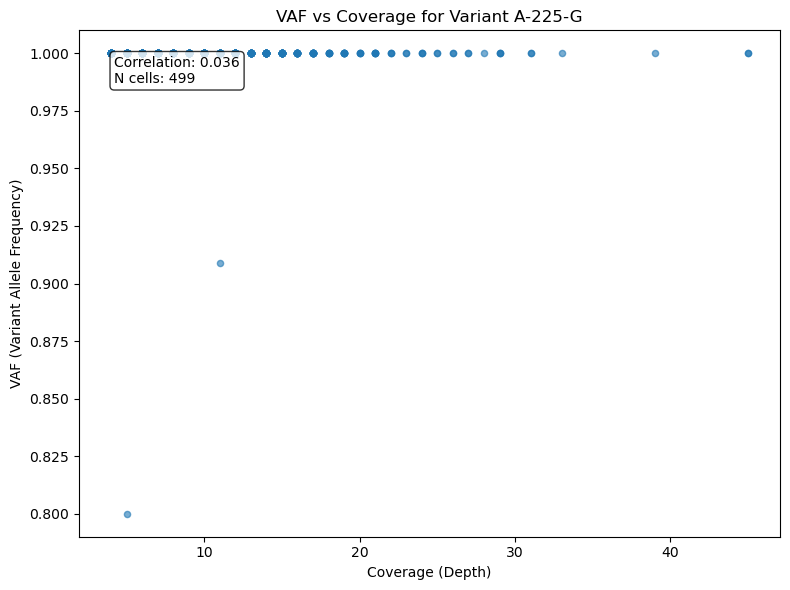

Variant A-225-G:
  Coverage range: 4.0 - 45.0
  Mean coverage: 10.5
  VAF range: 0.800 - 1.000
  Correlation (VAF vs Coverage): 0.036
---
Variant A-2573-G: Insufficient data points (0)
Variant A-2620-g: Insufficient data points (0)
Variant A-4148-G: Insufficient data points (1)
Variant A-5585-G: Insufficient data points (2)
Variant A-64-C: Insufficient data points (0)
Variant A-8206-G: Insufficient data points (0)
Variant A-822-G: Insufficient data points (1)
Variant A-9342-G: Insufficient data points (0)
Variant C-11485-T: Insufficient data points (1)
Variant C-11684-T: Insufficient data points (1)
Variant C-12758-T: Insufficient data points (1)
Variant C-13006-T: Insufficient data points (1)
Variant C-13039-T: Insufficient data points (0)
Variant C-13163-T: Insufficient data points (1)
Variant C-13830-T: Insufficient data points (1)


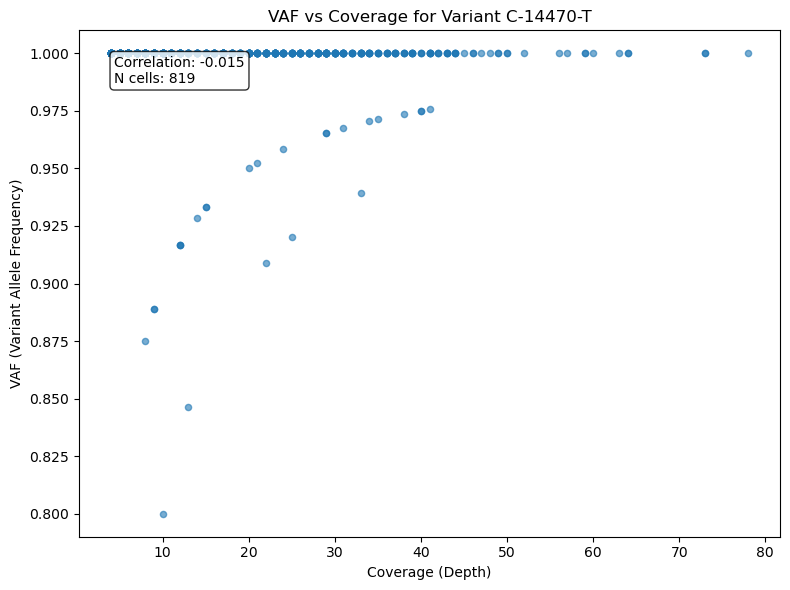

Variant C-14470-T:
  Coverage range: 4.0 - 78.0
  Mean coverage: 16.1
  VAF range: 0.800 - 1.000
  Correlation (VAF vs Coverage): -0.015
---
Variant C-15306-T: Insufficient data points (1)
Variant C-15784-T: Insufficient data points (1)


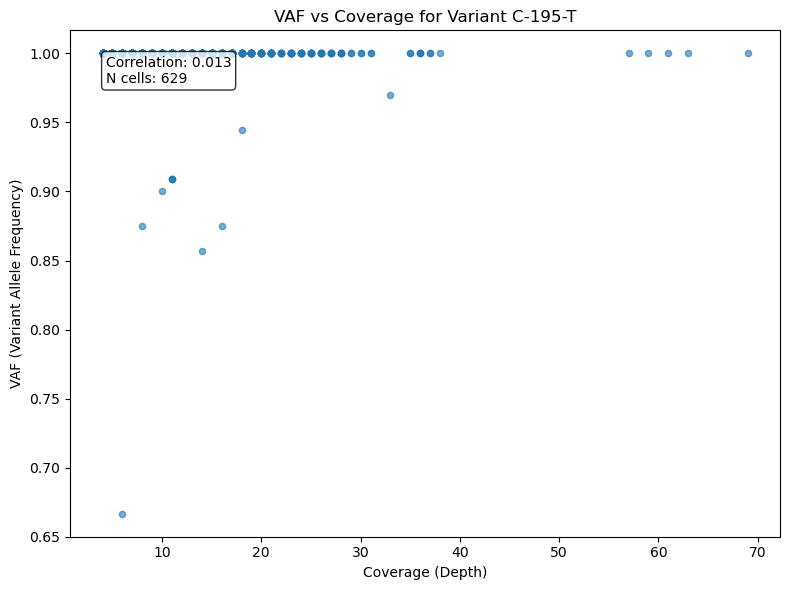

Variant C-195-T:
  Coverage range: 4.0 - 69.0
  Mean coverage: 12.0
  VAF range: 0.667 - 1.000
  Correlation (VAF vs Coverage): 0.013
---
Variant C-3264-t: Insufficient data points (0)


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Get the matrices and variant info
vaf_matrix = mgatk.obsm['variant_vaf']        # cells x variants
coverage_matrix = mgatk.obsm['variant_coverage']  # cells x variants  
variant_names = mgatk.uns['variant_names']

# For variants in your confident_variants
for i, variant_idx in enumerate(confident_variants.index[:30]):  # Plot top 5 confident variants
    # variant_idx is already the integer index we need
    variant_name = variant_names[variant_idx]  # Get the actual variant name string
    try:
        variant_idx = confident_variants.index[i]  # Get the actual variant index
        # Find the index of this variant in the variant_names list
        variant_idx = variant_names.index(variant_name)
        
        # Get VAF and coverage values for this variant across all cells
        vaf_values = vaf_matrix[:, variant_idx]
        coverage_values = coverage_matrix[:, variant_idx]
        
        # Filter for cells with non-zero VAF and valid coverage
        mask = (vaf_values > 0) & (coverage_values > 0)
        
        if mask.sum() > 5:  # Need at least 5 points for meaningful plot
            filtered_vaf = vaf_values[mask]
            filtered_coverage = coverage_values[mask]
            
            # Create scatter plot
            fig, ax = plt.subplots(1, 1, figsize=(8, 6))
            
            scatter = ax.scatter(filtered_coverage, filtered_vaf, alpha=0.6, s=20)
            ax.set_xlabel('Coverage (Depth)')
            ax.set_ylabel('VAF (Variant Allele Frequency)')
            ax.set_title(f'VAF vs Coverage for Variant {variant_name}')
            
            # Add statistics
            if len(filtered_coverage) > 1 and len(set(filtered_coverage)) > 1:
                correlation = np.corrcoef(filtered_coverage, filtered_vaf)[0, 1]
            else:
                correlation = np.nan
                
            ax.text(0.05, 0.95, f'Correlation: {correlation:.3f}\nN cells: {len(filtered_vaf)}', 
                    transform=ax.transAxes, verticalalignment='top', 
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
            
            plt.tight_layout()
            plt.show()
            
            # Print summary
            print(f"Variant {variant_name}:")
            print(f"  Coverage range: {filtered_coverage.min():.1f} - {filtered_coverage.max():.1f}")
            print(f"  Mean coverage: {filtered_coverage.mean():.1f}")
            print(f"  VAF range: {filtered_vaf.min():.3f} - {filtered_vaf.max():.3f}")
            print(f"  Correlation (VAF vs Coverage): {correlation:.3f}")
            print("---")
        else:
            print(f"Variant {variant_name}: Insufficient data points ({mask.sum()})")
            
    except Exception as e:
        print(f"Error processing variant {variant_name}: {e}")

In [10]:
import numpy as np
import pandas as pd

# Get the matrices
vaf_matrix = mgatk.obsm['variant_vaf'].copy()  # Make a copy to modify
coverage_matrix = mgatk.obsm['variant_coverage']
confident_matrix = mgatk.obsm['variant_confident']
variant_names = mgatk.uns['variant_names']
variant_summary = mgatk.uns['variant_summary']

print(f"Original VAF matrix shape: {vaf_matrix.shape}")
print(f"Non-zero VAF values before filtering: {(vaf_matrix > 0).sum()}")

# Count variants with at least one expressing cell before filtering
variants_with_expression_before = (vaf_matrix > 0).any(axis=0).sum()
print(f"Variants with at least one expressing cell before filtering: {variants_with_expression_before}")

# Create high-quality filtered VAF matrix
high_quality_vaf_matrix = vaf_matrix.copy()
variant_names_list = []
# For each variant, apply cell-level quality filters
for i, variant_name in enumerate(variant_names):
    # Get variant-level statistics
    variant_stats = variant_summary.iloc[i]
    strand_concordance = variant_stats['strand_concordance']
    variance = variant_stats['variance'] 
    mean_coverage = variant_stats['mean_coverage']
    
    # Get cell-level data for this variant
    cell_vaf = vaf_matrix[:, i]
    cell_coverage = coverage_matrix[:, i]
    cell_confident = confident_matrix[:, i]
    
    # Define quality criteria for this variant's cells
    quality_mask = (
        (strand_concordance >= 0.5) &  # Variant-level criterion
        (mean_coverage >= 20) &        # Variant-level criterion
        (cell_vaf >= 0.1)        # Cell-level: VAF > 10%
    )
    
    # Set non-qualifying cells to 0 for this variant
    high_quality_vaf_matrix[~quality_mask, i] = 0

print(f"Non-zero VAF values after high-quality filtering: {(high_quality_vaf_matrix > 0).sum()}")
print(f"Percentage of calls retained: {(high_quality_vaf_matrix > 0).sum() / (vaf_matrix > 0).sum() * 100:.1f}%")

# Count variants with at least one expressing cell after filtering
variants_with_expression_after = (high_quality_vaf_matrix > 0).any(axis=0).sum()
print(f"Variants with at least one expressing cell after filtering: {variants_with_expression_after}")
print(f"Percentage of variants retained: {variants_with_expression_after / variants_with_expression_before * 100:.1f}%")

# Count variants completely eliminated by filtering
variants_eliminated = variants_with_expression_before - variants_with_expression_after
print(f"Variants completely eliminated by filtering: {variants_eliminated}")
print("variants left" , variants_with_expression_after)
# Store the high-quality filtered matrix
mgatk.obsm['variant_vaf_high_quality'] = high_quality_vaf_matrix

# Now you can use this filtered matrix for analysis
print("\nHigh-quality filtered VAF matrix stored in mgatk.obsm['variant_vaf_high_quality']")

Original VAF matrix shape: (1475, 1083)
Non-zero VAF values before filtering: 24046
Variants with at least one expressing cell before filtering: 694
Non-zero VAF values after high-quality filtering: 0
Percentage of calls retained: 0.0%
Variants with at least one expressing cell after filtering: 0
Percentage of variants retained: 0.0%
Variants completely eliminated by filtering: 694
variants left 0

High-quality filtered VAF matrix stored in mgatk.obsm['variant_vaf_high_quality']


In [11]:
# Boolean mask: True for variants with at least one retained (non-zero) cell
high_quality_mask = (high_quality_vaf_matrix > 0).any(axis=0)

# Get corresponding variant names
high_quality_variant_names = np.array(variant_names)[high_quality_mask]
print(high_quality_variant_names)
print(len(high_quality_variant_names))

## Flip variants to match format 
converted = [f"MT-{alt}-{pos}-{ref}" for ref, pos, alt in (v.split('-') for v in high_quality_variant_names)]
print(converted)

required_columns = ["chr", "pos", "ref", "alt"]

genebe_df = pd.DataFrame(
    [v.split('-') for v in converted],
    columns=["chr","ref", "pos", "alt"]
)
genebe_df = genebe_df[required_columns]

print(genebe_df.head())

[]
0
[]
Empty DataFrame
Columns: [chr, pos, ref, alt]
Index: []


In [12]:
import genebe as gnb
annotated_PBMC = gnb.annotate_dataframe_variants(genebe_df,use_ensembl=True,use_refseq=False, genome='hg38', flatten_consequences=False)

ModuleNotFoundError: No module named 'genebe'

In [ ]:
annotated_PBMC.to_csv('PBMC_PostMortem_genebe.csv', index=False)

In [13]:
#Gene classification 
gene_classification = {
    'MT-ND1': 'Complex I',
    'MT-ND2': 'Complex I',
    'MT-ND3': 'Complex I',
    'MT-ND4': 'Complex I',
    'MT-ND4L': 'Complex I',
    'MT-ND5': 'Complex I',
    'MT-ND6': 'Complex I',
    'MT-CO1': 'Complex IV',
    'MT-CO2': 'Complex IV',
    'MT-CO3': 'Complex IV',
    'MT-CYB': 'Complex III',
    'MT-ATP6': 'Complex V',
    'MT-ATP8': 'Complex V',
    'MT-RNR1': 'rRNA',
    'MT-RNR2': 'rRNA',
    'MT-TF': 'tRNA',  
    'MT-TV': 'tRNA',
    'MT-TI': 'tRNA',
    'MT-TL1': 'tRNA',
    'MT-TL2': 'tRNA',
    'MT-TK': 'tRNA',
    'MT-TM': 'tRNA',
    'MT-TP': 'tRNA',
    'MT-TS1': 'tRNA',
    'MT-TS2': 'tRNA',
    'MT-TW': 'tRNA',
    'MT-TA': 'tRNA',
    'MT-TC': 'tRNA',
    'MT-TY': 'tRNA',
    'MT-TH': 'tRNA',
    'MT-TG': 'tRNA',
    'MT-TR': 'tRNA',
    'MT-TN': 'tRNA',
    'MT-TD': 'tRNA',
    'MT-TE': 'tRNA',
    'MT-TQ': 'tRNA'
}

In [14]:
# Create a copy of the dataframe and add the functional classification
annotated_PBMC_classified = annotated_PBMC.copy()
annotated_PBMC_classified['gene_functional_group'] = annotated_PBMC_classified['gene_symbol'].map(gene_classification)

# Handle any genes not in the classification (mark as 'Other')
annotated_PBMC_classified['gene_functional_group'] = annotated_PBMC_classified['gene_functional_group'].fillna('Other')

# Create a 2x2 subplot layout for the pie charts
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 16))  # Increased figure size

# Function to prepare data for pie chart (handle NaN values and limit categories)
def prepare_pie_data(series, max_categories=20):
    # Count values, excluding NaN
    value_counts = series.value_counts(dropna=True)
    
    # If there are more categories than max_categories, group the smallest ones as "Other"
    if len(value_counts) > max_categories:
        top_categories = value_counts.head(max_categories - 1)
        other_count = value_counts.iloc[max_categories - 1:].sum()
        
        # Create new series with "Other" category
        pie_data = top_categories.copy()
        pie_data['Other'] = other_count
    else:
        pie_data = value_counts
    
    return pie_data

# 1. Gene Functional Group pie chart (using your classification)
gene_functional_data = prepare_pie_data(annotated_PBMC_classified['gene_functional_group'])
colors1 = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#ff99cc', '#c2c2f0']  # Custom colors for complexes

# Option 1: Use pctdistance and labeldistance to control spacing
wedges1, texts1, autotexts1 = ax1.pie(gene_functional_data.values, labels=gene_functional_data.index, 
                                       autopct='%1.1f%%', startangle=90, 
                                       colors=colors1[:len(gene_functional_data)],
                                       pctdistance=0.85,    # Distance of percentage labels from center
                                       labeldistance=1.1)   # Distance of category labels from center

# Adjust text properties to prevent overlap
for autotext in autotexts1:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

for text in texts1:
    text.set_fontsize(11)

ax1.set_title(f'Variants by Mitochondrial Functional Group\n(Total variants: {len(annotated_PBMC)})', 
              fontsize=14, fontweight='bold', pad=20)

# 2. Effect pie chart with adjusted spacing
effect_data = prepare_pie_data(annotated_PBMC['effect'])
wedges2, texts2, autotexts2 = ax2.pie(effect_data.values, labels=effect_data.index, 
                                       autopct='%1.1f%%', startangle=90,
                                       pctdistance=0.85, labeldistance=1.1)

for autotext in autotexts2:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

for text in texts2:
    text.set_fontsize(11)

ax2.set_title(f'Variants by Effect\n(Total variants: {len(annotated_PBMC)})', 
              fontsize=14, fontweight='bold', pad=20)

# 3. ACMG Classification pie chart
acmg_data = prepare_pie_data(annotated_PBMC['acmg_classification'])
if len(acmg_data) > 0:
    wedges3, texts3, autotexts3 = ax3.pie(acmg_data.values, labels=acmg_data.index, 
                                           autopct='%1.1f%%', startangle=90,
                                           pctdistance=0.85, labeldistance=1.1)
    
    for autotext in autotexts3:
        autotext.set_fontsize(10)
        autotext.set_fontweight('bold')
        autotext.set_color('white')
    
    for text in texts3:
        text.set_fontsize(11)
    
    ax3.set_title(f'Variants by ACMG Classification\n(Total classified: {acmg_data.sum()})', 
                  fontsize=14, fontweight='bold', pad=20)
else:
    ax3.text(0.5, 0.5, 'No ACMG Classifications\nAvailable', ha='center', va='center', fontsize=12)
    ax3.set_title('ACMG Classification', fontsize=14, fontweight='bold', pad=20)

# 4. ClinVar Classification pie chart
clinvar_data = prepare_pie_data(annotated_PBMC['clinvar_classification'])
if len(clinvar_data) > 0:
    wedges4, texts4, autotexts4 = ax4.pie(clinvar_data.values, labels=clinvar_data.index, 
                                           autopct='%1.1f%%', startangle=90,
                                           pctdistance=0.85, labeldistance=1.1)
    
    for autotext in autotexts4:
        autotext.set_fontsize(10)
        autotext.set_fontweight('bold')
        autotext.set_color('white')
    
    for text in texts4:
        text.set_fontsize(11)
    
    ax4.set_title(f'Variants by ClinVar Classification\n(Total classified: {clinvar_data.sum()})', 
                  fontsize=14, fontweight='bold', pad=20)
else:
    ax4.text(0.5, 0.5, 'No ClinVar Classifications\nAvailable', ha='center', va='center', fontsize=12)
    ax4.set_title('ClinVar Classification', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout(pad=3.0)  # Add more padding between subplots
plt.show()

# Print summary statistics for each category
print("=== SUMMARY STATISTICS ===")
print(f"\n1. Mitochondrial Functional Group Distribution:")
functional_summary = annotated_PBMC_classified['gene_functional_group'].value_counts(dropna=True)
print(f"   Total functional groups represented: {len(functional_summary)}")
print(f"   Most common functional group: {functional_summary.index[0]} ({functional_summary.iloc[0]} variants)")
print(f"   All functional groups:")
for group, count in functional_summary.items():
    print(f"      {group}: {count} variants ({count/len(annotated_PBMC)*100:.1f}%)")

print(f"\n2. Individual Gene Symbol Distribution:")
gene_summary = annotated_PBMC['gene_symbol'].value_counts(dropna=True)
print(f"   Total genes represented: {len(gene_summary)}")
print(f"   Most common gene: {gene_summary.index[0]} ({gene_summary.iloc[0]} variants)")
print(f"   Top 10 genes:")
for i, (gene, count) in enumerate(gene_summary.head(10).items()):
    functional_group = gene_classification.get(gene, 'Other')
    print(f"      {i+1}. {gene} ({functional_group}): {count} variants ({count/len(annotated_PBMC)*100:.1f}%)")

print(f"\n3. Effect Distribution:")
effect_summary = annotated_PBMC['effect'].value_counts(dropna=True)
print(f"   Total effect types: {len(effect_summary)}")
if len(effect_summary) > 0:
    print(f"   Most common effect: {effect_summary.index[0]} ({effect_summary.iloc[0]} variants)")
    print(f"   All effects:")
    for effect, count in effect_summary.items():
        print(f"      {effect}: {count} variants ({count/len(annotated_PBMC)*100:.1f}%)")

acmg_summary = annotated_PBMC['acmg_classification'].value_counts(dropna=True)
print(f"\n4. ACMG Classification Distribution:")
print(f"   Total ACMG classified variants: {annotated_PBMC['acmg_classification'].notna().sum()}")
print(f"   Unclassified variants: {annotated_PBMC['acmg_classification'].isna().sum()}")
for classification, count in acmg_summary.items():
    print(f"      {classification}: {count} variants")

print(f"\n5. ClinVar Classification Distribution:")
clinvar_summary = annotated_PBMC['clinvar_classification'].value_counts(dropna=True)
print(f"   Total ClinVar classified variants: {annotated_PBMC['clinvar_classification'].notna().sum()}")
print(f"   Unclassified variants: {annotated_PBMC['clinvar_classification'].isna().sum()}")
if len(clinvar_summary) > 0:
    for classification, count in clinvar_summary.items():
        print(f"      {classification}: {count} variants")

NameError: name 'annotated_PBMC' is not defined

In [ ]:
## Import mitoTIP dataframe to look at tRNA variants only 
mitoTIP = pd.read_csv('/Users/lucascortes/Library/CloudStorage/OneDrive-Personal/Documents/Work/Pickett/ATAC-Seq/Usefull_Stuff/mitotip_scores.txt', sep='\t')
mitoTIP.head(20)

,Position,rCRS,Alt,MitoTIP_Score,Quartile,Count,Percentage,Mitomap_Status
0,577,G,:,20.3833,Q1,0,0.0,Absent
1,577,G,A,17.7500,Q1,0,0.0,Absent
2,577,G,C,17.7500,Q1,0,0.0,Absent
3,577,G,T,17.7500,Q1,0,0.0,Absent
4,578,T,:,18.6851,Q1,0,0.0,Absent
5,578,T,A,18.6851,Q1,0,0.0,Absent
6,578,T,C,16.6004,Q1,0,0.0,Absent
7,578,T,G,18.6851,Q1,0,0.0,Absent
8,579,T,:,17.6526,Q1,0,0.0,Absent
9,579,T,A,17.6526,Q1,0,0.0,Absent


In [ ]:
## Dataframe containing tRNA variants likely or poissbly pathogenic as per mitoTIP scoring method 
mitoTIP_filtered = mitoTIP[(mitoTIP['Quartile'] == 'Q2') | (mitoTIP['Quartile'] == 'Q1')]
mitoTIP_filtered.head(20)

Empty DataFrame
Columns: [Position, rCRS, Alt, MitoTIP_Score, Quartile, Count, Percentage, Mitomap_Status]
Index: []
